## Analise de preços
- Analisa os preços dos produtos registrados
- Entendimento de como os evoluem e como os paramentros funcionam
- Guarda sempre o min historico para comparar o preço

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from database import connect



conn = connect()
df = pd.DataFrame(
    conn.execute("SELECT product, price, date FROM prices ORDER BY date").fetchall()
)
conn.close()

df['date'] = pd.to_datetime(df['date'])
df.shape

(24, 3)

In [14]:
df.groupby(df['date'].dt.date).size()

date
2026-08-07     3
2026-08-10    10
2026-08-11     8
2026-08-12     3
dtype: int64

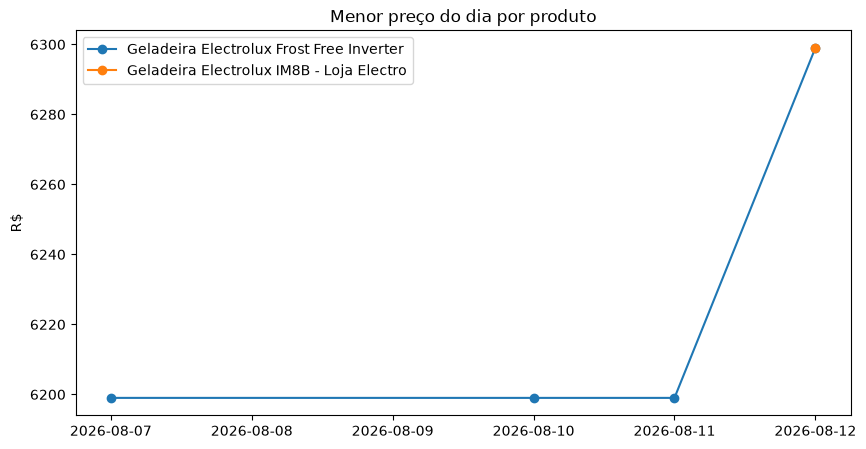

In [15]:
df['dia'] = df['date'].dt.date
diario = df.groupby(['product', 'dia'])['price'].min().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for nome, grupo in diario.groupby('product'):
    ax.plot(grupo['dia'], grupo['price'], marker='o', label=nome[:40])
ax.set_ylabel('R$')
ax.set_title('Menor preço do dia por produto')
ax.legend()
plt.show()

In [16]:
df.groupby('product')['price'].agg(['count', 'min', 'mean', 'max'])

,count,min,mean,max
product,,,,
Geladeira Electrolux Frost Free Inverter 596L AutoSense 3 Portas Cor Black Inox Look (IM8B),23,6199.0,6503.545217,6955.06
Geladeira Electrolux IM8B - Loja Electrolux,1,6299.0,6299.000000,6299.00


- Minimo de historico até o momento: 6199 (12/08)
- Demonstra o preço mais baixo do dia, e qual a fonte, comparando os dados do dia e tirando o melhor
- Buraco de capturas em 08-09/08: cron registrado mas mudo, commit do workflow com e-mail não vinculado ao GitHub (ator inválido)
- Com mais semanas de trabalhos podemos criar uma base de preço e verificar a variancia